In [32]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

In [33]:
tools = c('singlem', 'sylph', 'singlem_dev')
publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'sylph', 'SingleM dev')
)
communities = paste0('marine',as.character(0))
d1 = data.table(expand.grid(tool = tools, community = communities))
d1[, tool2 := publication_names[tool, on = "tool", publication_name]]
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(tool, community){
    to_read = paste0('output_',tool,'/opal/',community,'.opal_report')
    return(fread(to_read))
}
d2 = d1[, readit(tool, community), by=list(tool,community, tool2)]

In [34]:
setnames(d2, c('tool', 'community', 'tool2', 'blah', 'rank', 'metric', 'sample', 'value'))
d3 = d2[blah != 'Gold standard', .(tool, community, rank, metric, value, tool2)]
d3[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]

In [35]:
fwrite(d3, 'accuracy_results.csv')# write out bc
fwrite(d3[metric == "Bray-curtis distance"], 'bray-curtis.csv', sep='\t')

In [36]:
s1 = dcast(d3, ...~metric, value.var='value')
s1[, c("tool", "tool2") := list(tool2, NULL)]

s1 = s1[order(rank, tool)]
fwrite(s1, 'opal_summary.csv', sep='\t')

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`stat_boxplot()`).”


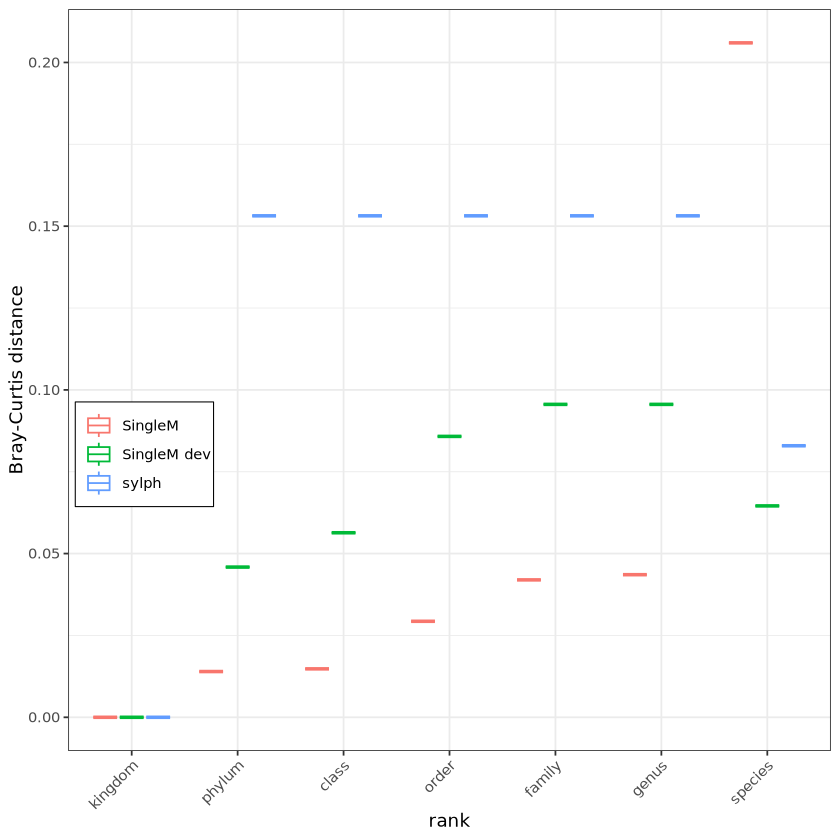

In [62]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1, aes(rank, `Bray-Curtis distance`, colour = tool)) +
   geom_boxplot() +
   scale_x_discrete(na.translate = FALSE) +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position=c(0.1,0.4)) +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3))

# Relationship between relative abundance and accuracy

In [38]:
truth_profiles = data.table(community=communities)
truth_profiles2 = truth_profiles[, fread(paste('truths/',community,'.condensed',sep='')), by=community]
truth_profiles2[, c("sample", "tool") := .(NULL, 'Gold standard')]

In [39]:
tool_profiles = data.table(expand.grid(tool = tools, community = communities))
tool_profiles2 = tool_profiles[
    ,
    fread(paste('output_',tool,'/',tool,'/',community,'.profile',sep='')),
    by=list(tool,community)
]
tool_profiles2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = factor(publication_names[tool, on = "tool", publication_name]))
]

all_profiles = rbind(truth_profiles2, tool_profiles2)
all_profiles[, relabu := coverage / sum(coverage), by = list(community, tool)]
m = dcast(all_profiles, taxonomy + community ~ tool, value.var = c("relabu", "coverage"), fill = 0)
setnames(m, names(m), gsub("_", "__", names(m)))
setnames(m, c("relabu__Gold standard", "coverage__Gold standard"), c("true_relabu", "true_coverage"))

In [68]:
format_table <- function(m) {
    ra_cols <- grep("^relabu_|_relabu$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^coverage_|_coverage$", names(m))), with = FALSE]
    mtmp[
        ,
        c(ra_cols, "taxonomy") := c(
            lapply(.SD[, ra_cols, with = FALSE], scales::label_percent()),
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        )
    ][]
}


In [69]:
# kingdom
format_table(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";p__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,d__Bacteria,100%,100%,100%,100%


In [70]:
# phylum
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";c__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,d__Bacteria; p__Actinobacteriota,15.3%,15.42%,12.22%,0.0%
marine0,d__Bacteria; p__Bacteroidota,2.0%,2.08%,2.14%,2.4%
marine0,d__Bacteria; p__Elusimicrobiota,3.2%,2.59%,2.03%,4.0%
marine0,d__Bacteria; p__Firmicutes,10.4%,10.98%,9.34%,12.2%
marine0,d__Bacteria; p__Firmicutes_C,41.5%,41.34%,44.97%,49.3%
marine0,d__Bacteria; p__Proteobacteria,27.5%,26.24%,27.70%,32.2%


In [71]:
# class
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";o__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,p__Actinobacteriota; c__Actinomycetia,15.32%,15.42%,12.22%,0.00%
marine0,p__Bacteroidota; c__Bacteroidia,2.01%,2.08%,2.14%,2.39%
marine0,p__Elusimicrobiota; c__Elusimicrobia,3.18%,2.59%,2.03%,3.96%
marine0,p__Firmicutes; c__Bacilli,10.44%,10.98%,9.34%,12.24%
marine0,p__Firmicutes_C; c__Negativicutes,41.54%,41.34%,44.97%,49.27%
marine0,p__Proteobacteria; c__Alphaproteobacteria,3.65%,3.42%,2.61%,4.17%
marine0,p__Proteobacteria; c__Gammaproteobacteria,23.87%,22.67%,25.10%,27.98%


In [72]:
# order
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";f__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,c__Actinomycetia; o__Actinomycetales,15.316%,12.418%,7.41%,0.000%
marine0,c__Bacteroidia; o__Flavobacteriales,2.011%,2.082%,2.14%,2.386%
marine0,c__Elusimicrobia; o__Elusimicrobiales,3.178%,2.595%,2.03%,3.960%
marine0,c__Bacilli; o__Erysipelotrichales,1.998%,2.067%,2.31%,2.363%
marine0,c__Bacilli; o__Lactobacillales,8.440%,8.078%,7.03%,9.872%
marine0,c__Negativicutes; o__Veillonellales,41.536%,41.343%,44.97%,49.266%
marine0,c__Alphaproteobacteria; o__Sphingomonadales,3.650%,3.416%,2.61%,4.173%
marine0,c__Gammaproteobacteria; o__UBA4486,23.872%,22.577%,25.10%,27.980%


In [73]:
# family
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";g__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,o__Actinomycetales; f__Kineosporiaceae,15.316%,10.834%,6.249%,0.000%
marine0,o__Flavobacteriales; f__Flavobacteriaceae,2.011%,2.082%,2.144%,2.386%
marine0,o__Elusimicrobiales; f__Elusimicrobiaceae,3.178%,2.595%,2.028%,3.960%
marine0,o__Erysipelotrichales; f__Coprobacillaceae,1.998%,2.067%,2.310%,2.363%
marine0,o__Lactobacillales; f__Listeriaceae,2.761%,3.167%,2.692%,3.179%
marine0,o__Lactobacillales; f__Streptococcaceae,5.679%,4.911%,3.773%,6.693%
marine0,o__Veillonellales; f__Veillonellaceae,41.536%,41.343%,44.973%,49.266%
marine0,o__Sphingomonadales; f__Sphingomonadaceae,3.650%,3.416%,2.609%,4.173%
marine0,o__UBA4486; f__UBA4486,23.872%,22.577%,25.096%,27.980%


In [74]:
# How well does genus level rescue some of the missing genomes? First need to remake the table with genus level, annoying since kraken profiles are filled, when the rest aren't.
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";s__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,f__Kineosporiaceae; g__Kineosporia,15.316%,10.717%,6.249%,0.000%
marine0,f__Flavobacteriaceae; g__Flavobacterium,2.011%,2.082%,2.144%,2.386%
marine0,f__Elusimicrobiaceae; g__UBA1174,3.178%,2.595%,2.028%,3.960%
marine0,f__Coprobacillaceae; g__Beduini,1.998%,2.067%,2.310%,2.363%
marine0,f__Listeriaceae; g__Listeria_A,2.761%,3.167%,2.692%,3.179%
marine0,f__Streptococcaceae; g__Streptococcus,5.679%,4.911%,3.773%,6.693%
marine0,f__Veillonellaceae; g__Veillonella,41.536%,41.167%,44.973%,49.266%
marine0,f__Sphingomonadaceae; g__Sphingomonas,3.650%,3.416%,2.609%,4.173%
marine0,f__UBA4486; g__SZUA-592,23.872%,22.577%,25.096%,27.980%


In [75]:
# Species level
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])

taxonomy,community,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
g__Kineosporia; s__Kineosporia sp018499875,marine0,0.0000%,2.668%,0.000%,0.0000%
g__Flavobacterium; s__Flavobacterium hydatis,marine0,2.0106%,2.082%,2.144%,2.3856%
g__UBA1174; s__UBA1174 sp900556855,marine0,3.1778%,2.272%,2.028%,3.9597%
g__Beduini; s__Beduini massiliensis,marine0,1.9981%,2.067%,2.310%,2.3631%
g__Listeria_A; s__Listeria_A newyorkensis,marine0,2.7608%,2.727%,2.692%,3.1790%
g__Streptococcus; s__Streptococcus lactarius,marine0,2.0259%,1.026%,0.781%,2.3534%
g__Streptococcus; s__Streptococcus mitis_BM,marine0,3.6531%,3.049%,2.859%,4.3400%
g__Veillonella; s__Veillonella atypica,marine0,0.0000%,6.612%,0.000%,0.0000%
g__Veillonella; s__Veillonella nakazawae,marine0,0.0000%,3.548%,0.000%,0.0000%


In [48]:
# read proportions
fix_names <- function(old)
    purrr::map_chr(strsplit(old, "; ?"), function(x) paste0(x, collapse = "; "))

params <- data.table(expand.grid(div = c(2, 3, 4, 6), top = c(2, 5, 10)))
read_hits <- function(file) {
    tbl <- fread(file)[, id := seq_len(.N)]
    setnames(tbl, grep(value = TRUE, "; ?", names(tbl)), fix_names)
}
bhs <- params[
    ,
    list(tbl = list(read_hits(paste0("debug/div", div, "top", top, "/marine0_hits.tsv"))[, c("div", "top") := list(div, top)])),
    by = list(div, top)
]
bh <- bhs[, dplyr::bind_rows(tbl)]

In [49]:
sp_cols <- grep(value = TRUE, "; s__", names(bh))
bh[
    ,
    (sp_cols) := lapply(.SD, function(x) dplyr::case_when(is.na(x) ~ 0, div == 2 & x %in% c(1, 3) ~ 1, x > 0 ~ div, TRUE ~ x)),
    .SDcols = sp_cols
]
gn_cols <- grep(value = TRUE, "; g__[^;]+$", names(bh))
bh[
    ,
    (gn_cols) := lapply(.SD, function(x) dplyr::case_when(is.na(x) ~ 0, div == 2 & top == 2 & x %in% c(1, 3) ~ 1, x > 0 ~ top, TRUE ~ x)),
    .SDcols = gn_cols
]
#bhl[, score := ifelse(value == 3, 1, ifelse(value == 2, ifelse(grepl("; s__", variable), div, top), value))]

In [50]:
bhs <- bh[
    ,
    lapply(.SD, function(x) ifelse(any(x > 0), min(x[x > 0]), 0)),
    .SDcols = c(sp_cols, gn_cols),
    by = list(id, sample, marker, domain, coverage)
]

In [51]:
dim(bhs)
bhs[1:5, 1:10]

[1]  1039 12876

id,sample,marker,domain,coverage,Root; d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Listeriaceae; g__Listeria_A; s__Listeria_A grandensis,Root; d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Listeriaceae; g__Listeria_A; s__Listeria_A cornellensis,Root; d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Listeriaceae; g__Listeria_A; s__Listeria_A newyorkensis,Root; d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Listeriaceae; g__Listeria; s__Listeria seeligeri,Root; d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Listeriaceae; g__Listeria; s__Listeria welshimeri
<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,marine0.1,S3.1.ribosomal_protein_L2_rplB,Bacteria;Archaea,1.65,1,1,1,2,2
2,marine0.1,S3.1.ribosomal_protein_L2_rplB,Bacteria;Archaea,13.20,0,0,0,0,0
3,marine0.1,S3.1.ribosomal_protein_L2_rplB,Bacteria;Archaea,23.10,0,0,0,0,0
4,marine0.1,S3.1.ribosomal_protein_L2_rplB,Bacteria;Archaea,1.65,0,0,0,0,0
5,marine0.1,S3.1.ribosomal_protein_L2_rplB,Bacteria;Archaea,1.65,0,0,0,0,0


In [52]:
format_props <- function(m) {
    feat_cols <- names(m)[!names(m) %in% c("sample", "marker", "domain", "coverage")]
    m[
        ,
        c(list("marker" = marker, "coverage" = coverage),
          lapply(.SD, function(x) formatC(x, digits = 3))),
        .SDcols = -c("marker", "coverage")
    ]
}

In [76]:
# look at Veillonella atypica/tobetsuensis
format_table(m[grepl("g__Veillonella", taxonomy)])

taxonomy,community,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
f__Veillonellaceae; g__Veillonella,marine0,0%,5.4%,7.9%,0%
g__Veillonella; s__Veillonella atypica,marine0,0%,6.6%,0.0%,0%
g__Veillonella; s__Veillonella nakazawae,marine0,0%,3.5%,0.0%,0%
g__Veillonella; s__Veillonella tobetsuensis,marine0,42%,25.6%,37.0%,49%


In [56]:
vah = bhs[rowSums(bhs[, grep(value = TRUE, "g__Veillonella", names(bhs)), with = FALSE]) > 0 & coverage > 2][
    grepl("Bacteria", domain),
    -c("sample", "domain")
]
vah_mks <- vah[
    ,
    lapply(.SD, function(x) any(x %in% c(1, 2))),
    .SDcols = -"coverage",
    by = list(marker)
][
    ,
    lapply(.SD, sum),
    .SDcols = -"marker"
][, as.list(sort(unlist(.SD), decreasing = TRUE)), .SDcols = function(x) x > 0]
vah_mks

Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella tobetsuensis,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella atypica,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella nakazawae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp002959755,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp003463825,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella infantium,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella rogosae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900538355,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900550175,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella dispar,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella parvula,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella parvula_A,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900552445,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900545205,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella denticariosi,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella rodentium,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900757715,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella caviae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp018367495,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp009929605,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp905209685,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900552715,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900549845,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900765235,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella_A; s__Veillonella_A criceti,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp902834965,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella montpellierensis,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__F0422; s__F0422 sp003992055,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella_A; s__Veill

In [57]:
vah[, length(unique(marker))] * 0.35
length(vah_mks)

[1] 12.25

[1] 39

In [58]:
format_props(vah[order(marker), c("id", "marker", "coverage", names(vah_mks)), with = FALSE])

marker,coverage,id,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella tobetsuensis,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella atypica,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella nakazawae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp002959755,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp003463825,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella infantium,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella rogosae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900538355,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900550175,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella dispar,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella parvula,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella parvula_A,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900552445,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900545205,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella denticariosi,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella rodentium,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900757715,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella caviae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp018367495,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp009929605,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp905209685,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900552715,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900549845,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900765235,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella_A; s__Veillonella_A criceti,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp902834965,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella montpellierensis,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__F0422; s__F0422 sp003992055,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veil

In [79]:
# look at Kineosporia genus/Actinomycetia class
format_table(m[grepl("p__Actinobacteriota", taxonomy)])

taxonomy,community,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
p__Actinobacteriota; c__Actinomycetia,marine0,0%,3.01%,4.8%,0%
c__Actinomycetia; o__Actinomycetales,marine0,0%,1.58%,1.2%,0%
o__Actinomycetales; f__Kineosporiaceae,marine0,0%,0.12%,0.0%,0%
f__Kineosporiaceae; g__Kineosporia,marine0,15%,8.05%,6.2%,0%
g__Kineosporia; s__Kineosporia sp018499875,marine0,0%,2.67%,0.0%,0%


In [63]:
kibh = bh[rowSums(bh[, grep(value = TRUE, "g__Kineosporia", names(bh)), with = FALSE]) > 0][
    grepl("Bacteria", domain),
    -c("sample", "domain")
]
kibh_mks <- kibh[
    ,
    lapply(.SD, function(x) any(x %in% c(1, 2))),
    .SDcols = -c("top", "div", "coverage"),
    by = list(marker)
][
    ,
    lapply(.SD, sum),
    .SDcols = -"marker"
][, as.list(sort(unlist(.SD), decreasing = TRUE)), .SDcols = function(x) x > 0]
kibh_mks

Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia; s__Kineosporia sp018499875,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia; s__Kineosporia aurantiaca,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Streptomycetales; f__Streptomycetaceae; g__Streptomyces,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__JACYXE01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__JADJPO01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__R-H-3,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Mobilicoccus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Quadrisphaeraceae; g__Quadrisphaera,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Cellulomonadaceae; g__Xylanimonas,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Flexivirga,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Propionibacteriales; f__Nocardioidaceae; g__Nocardioides,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Cellulomonadaceae; g__Actinotalea,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__JAAYAH01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Streptomycetales; f__Streptomycetaceae; g__Streptomyces; s__Streptomyces violaceus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Streptomycetales; f__Streptomycetaceae; g__Streptomyces; s__Streptomyces sp018070565,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Streptomycetales; f__Streptomycetaceae; g__Streptomyces; s__Streptomyces fragilis,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Streptomycetales; f__Streptomycetaceae; g__Streptomyces; s__Streptomyces abyssomicinicus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Phycicoccus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Janibacter_A,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Ornithinimicrobium,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Yimella,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Arsenicicoccus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Branchiibius,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Humibacillus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Ornithinicoccus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Pedococcus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Serinicoccus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Terracoccus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__GCA-2748155,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__Geodermatophilus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineococcaceae; g__Kineococcus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__Modestobacter,Root; d__Bacteria; p__Actinobacteriota; c

In [64]:
format_props(kibh[, c("marker", "coverage", names(kibh_mks)[kibh_mks > 12]), with = FALSE])

marker,coverage,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia
<chr>,<dbl>,<chr>
S3.1.ribosomal_protein_L2_rplB,1.65,1
S3.1.ribosomal_protein_L2_rplB,11.50,1
S3.10.ribosomal_protein_S19_rpsS,1.65,0
S3.11.pheS,11.50,0
S3.11.pheS,1.65,0
S3.12.ribosomal_L1,3.30,2
S3.13.ribosomal_S9,9.89,1
S3.2.ribosomal_protein_L3_rplC,6.59,1
S3.3.ribosomal_protein_L14b_L23e_rplN,8.24,1
